# IPCA Asset Pricing: ALS vs Grassmannian

Apply **Instrumented Principal Component Analysis (IPCA)** to US stock returns,
following the asset pricing application in Kelly, Pruitt & Su (2019, 2020).

**Model:**
$$x_{i,t+1} = \beta_{i,t}' f_{t+1} + \varepsilon_{i,t+1}, \qquad \beta_{i,t} = \Gamma' z_{i,t}$$

**Data:**
- CRSP monthly excess stock returns (1965–2016)
- 94 firm characteristics from Gu et al. (2020), rank-transformed to $[-0.5, 0.5]$

**Estimators compared:**
- **ALS IPCA** — Alternating Least Squares
- **Grassmannian IPCA** — Riemannian Conjugate Gradient (pymanopt)

**Evaluation:**
- In-sample total $R^2$ (realized factors) and predictive $R^2$ (mean factors)
- Out-of-sample total $R^2$ and predictive $R^2$
- Portfolio sorts by predicted expected returns

In [1]:
import sys, os, time
os.chdir(os.path.join(os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.als_ipca import ALSIPCA
from src.models.grassmanian_ipca import GrassmannManifoldIPCAEstimator

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Load & Prepare Data

In [2]:
# --- Returns ---
returns_df = pd.read_csv(
    'data/crsp_monthly_returns.csv',
    usecols=['PERMNO', 'YYYYMM', 'MthRet', 'MthCap'],
    dtype={'PERMNO': np.int64, 'YYYYMM': np.int64, 'MthRet': np.float32, 'MthCap': np.float64},
)
returns_df = returns_df[(returns_df['YYYYMM'] >= 196501) & (returns_df['YYYYMM'] <= 201812)].copy()
returns_df.dropna(subset=['MthRet'], inplace=True)

print(f"Returns: {returns_df.shape[0]:,} obs, "
      f"{returns_df['PERMNO'].nunique():,} stocks, "
      f"{returns_df['YYYYMM'].nunique()} months")
print(f"Date range: {returns_df['YYYYMM'].min()} – {returns_df['YYYYMM'].max()}")

Returns: 3,823,690 obs, 31,033 stocks, 624 months
Date range: 196501 – 201612


In [3]:
# --- Characteristics ---
chars_df = pd.read_csv('data/datashare.csv', dtype={'permno': np.int64, 'DATE': np.int64})
chars_df.rename(columns={'permno': 'PERMNO'}, inplace=True)
chars_df['YYYYMM'] = chars_df['DATE'] // 100
chars_df.drop(columns=['DATE'], inplace=True)
chars_df = chars_df[(chars_df['YYYYMM'] >= 196501) & (chars_df['YYYYMM'] <= 201812)].copy()

char_cols = [c for c in chars_df.columns if c not in ['PERMNO', 'YYYYMM']]
print(f"Number of characteristics: {len(char_cols)}")

# Cross-sectional rank transform to [-0.5, 0.5]
print("Rank-transforming characteristics...")
chars_df[char_cols] = chars_df.groupby('YYYYMM')[char_cols].rank(pct=True) - 0.5
chars_df[char_cols] = chars_df[char_cols].fillna(0).astype(np.float32)

print(f"Characteristics: {chars_df.shape[0]:,} obs, "
      f"{chars_df['PERMNO'].nunique():,} stocks")

Number of characteristics: 95
Rank-transforming characteristics...
Characteristics: 3,629,074 obs, 29,573 stocks


In [4]:
# --- Panel construction ---

# Merge returns and characteristics
panel = returns_df.merge(chars_df, on=['PERMNO', 'YYYYMM'], how='inner')
print(f"Merged panel: {panel.shape[0]:,} obs")
del returns_df, chars_df

# Filter to top 500 stocks by average market cap
avg_cap = panel.groupby('PERMNO')['MthCap'].mean()
top_stocks = avg_cap.nlargest(500).index
panel = panel[panel['PERMNO'].isin(top_stocks)].copy()
print(f"After filtering to top 500 stocks: {panel.shape[0]:,} obs")

# Load Rfree for excess returns
macro_df = pd.read_csv('data/macro/PredictorData2021 - Monthly.csv')
macro_df.rename(columns={'yyyymm': 'YYYYMM'}, inplace=True)
macro_df['YYYYMM'] = macro_df['YYYYMM'].astype(np.int64)

panel = panel.merge(macro_df[['YYYYMM', 'Rfree']], on='YYYYMM', how='inner')
panel['ExRet'] = panel['MthRet'] - panel['Rfree'].astype(np.float32)

# Build arrays
months = sorted(panel['YYYYMM'].unique())
stocks = sorted(panel['PERMNO'].unique())
T, N = len(months), len(stocks)
L = len(char_cols)

month_idx = {m: i for i, m in enumerate(months)}
stock_idx = {s: i for i, s in enumerate(stocks)}

returns_arr = np.full((T, N), np.nan, dtype=np.float32)
chars_arr = np.zeros((T, N, L), dtype=np.float32)

panel['t_idx'] = panel['YYYYMM'].map(month_idx)
panel['n_idx'] = panel['PERMNO'].map(stock_idx)

t_indices = panel['t_idx'].values.astype(int)
n_indices = panel['n_idx'].values.astype(int)
returns_arr[t_indices, n_indices] = panel['ExRet'].values.astype(np.float32)
chars_arr[t_indices, n_indices, :] = panel[char_cols].values.astype(np.float32)
del panel

# Lag characteristics: z_{i,t} predicts x_{i,t+1} (following KPS)
returns_arr = returns_arr[1:]       # returns from t=1 to T-1
chars_arr = chars_arr[:-1]          # characteristics from t=0 to T-2
months = months[1:]                 # align month labels with returns
T = T - 1

# Fill NaN returns with 0 (unbalanced panel handling)
nan_mask = np.isnan(returns_arr)
returns_filled = np.nan_to_num(returns_arr, nan=0.0)

print(f"\nFinal arrays (after lagging Z by 1 month):")
print(f"  Returns: {returns_arr.shape} (T={T}, N={N})")
print(f"  Characteristics: {chars_arr.shape} (T={T}, N={N}, L={L})")
print(f"  Non-NaN returns: {np.sum(~nan_mask):,} / {T*N:,} "
      f"({100*np.sum(~nan_mask)/(T*N):.1f}%)")

Merged panel: 3,663,604 obs
After filtering to top 500 stocks: 138,130 obs

Final arrays (after lagging Z by 1 month):
  Returns: (623, 500) (T=623, N=500)
  Characteristics: (623, 500, 95) (T=623, N=500, L=95)
  Non-NaN returns: 137,032 / 311,500 (44.0%)


## 2. Train / Test Split

In [5]:
split_date = 200412
split_idx = next(i for i, m in enumerate(months) if m > split_date)

train_rets = returns_filled[:split_idx]
train_Z = chars_arr[:split_idx]
test_rets = returns_filled[split_idx:]
test_Z = chars_arr[split_idx:]

# Keep raw returns (with NaN) for proper R² computation
train_rets_raw = returns_arr[:split_idx]
test_rets_raw = returns_arr[split_idx:]

T_train = split_idx
T_test = T - split_idx
K = 4  # number of factors (following KPS)

print(f"K = {K} factors")
print(f"Train: {T_train} months ({months[0]} – {months[split_idx-1]})")
print(f"Test:  {T_test} months ({months[split_idx]} – {months[-1]})")

K = 4 factors
Train: 479 months (196502 – 200412)
Test:  144 months (200501 – 201612)


## 3. Fit IPCA Models

In [6]:
# --- ALS IPCA ---
als = ALSIPCA(num_assets=N, num_fact=K, num_charact=L, win_len=T_train)

t0 = time.time()
Gamma_als, hist_als = als.fit(
    [train_rets, train_Z],
    max_iter=500, tol=1e-6,
    verbose=True,
)
als_time = time.time() - t0

# Extract ALS factors (K x T) -> (T x K)
f_als_train = als.factors.values.T  # (T_train, K)
lambda_als = als.Lambda.values      # (K,) mean factor

print(f"\nWall time: {als_time:.1f}s")
print(f"Final objective: {hist_als[-1]:.6f}")
print(f"Iterations: {als.n_iterations}")

Iteration    0: Objective = 1.556892
Iteration    1: Objective = 1.339969, Gamma change = 0.66553235, Factor change = 0.00000013
Iteration    2: Objective = 1.322851, Gamma change = 0.57717953, Factor change = 0.66324374
Iteration    3: Objective = 1.316241, Gamma change = 0.12363210, Factor change = 0.91808741
Iteration    4: Objective = 1.313399, Gamma change = 1.04594683, Factor change = 0.19203599
Iteration    5: Objective = 1.312222, Gamma change = 0.07515151, Factor change = 1.61332796
Iteration    6: Objective = 1.311686, Gamma change = 0.04471288, Factor change = 0.08036825
Iteration    7: Objective = 1.311398, Gamma change = 0.03107608, Factor change = 0.07065815
Iteration    8: Objective = 1.311218, Gamma change = 0.02203589, Factor change = 0.05231603
Iteration    9: Objective = 1.311091, Gamma change = 0.01690360, Factor change = 0.03642291
Iteration   10: Objective = 1.310994, Gamma change = 0.01629279, Factor change = 0.02835899
Iteration   11: Objective = 1.310916, Gamma

In [7]:
# --- Grassmannian IPCA ---
grass = GrassmannManifoldIPCAEstimator(
    num_assets=N, num_fact=K, num_charact=L, win_len=T_train,
)

t0 = time.time()
Gamma_grass, f_grass_train, hist_grass = grass.fit(
    [train_rets, train_Z],
    optimizer="ConjugateGradient",
    max_iterations=300,
    verbosity=2,
)
grass_time = time.time() - t0

# f_grass_train is already (T_train, K)
lambda_grass = f_grass_train.mean(axis=0)  # (K,) mean factor

print(f"\nWall time: {grass_time:.1f}s")
print(f"Final objective: {hist_grass[-1]:.6f}")

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
  1          +1.6590267700188612e+00    7.47556610e-01    
  2          +1.5388103794180177e+00    3.23472112e-01    
  3          +1.4872108299586979e+00    1.87604472e-01    
  4          +1.4503927682754207e+00    1.26532469e-01    
  5          +1.4151345284192980e+00    9.58446368e-02    
  6          +1.3766488204636387e+00    8.09100064e-02    
  7          +1.3621454833921021e+00    1.03550297e-01    
  8          +1.3498611348733600e+00    5.27405855e-02    
  9          +1.3476527041145399e+00    4.67087722e-02    
 10          +1.3448113741432668e+00    3.60462875e-02    
 11          +1.3426165000602774e+00    5.03957919e-02    
 12          +1.3371762735606740e+00    5.87383183e-02    
 13          +1.3336177731335388e+00    4.35942235e-02    
 14          +1.3320423346985033e+00    5.05043506e-02    
 15          +1.3309552627877432e+00    3.

## 4. In-Sample & Out-of-Sample $R^2$

Following KPS (2019):
- **Total $R^2$**: uses realized factor returns $\hat{f}_{t+1}$
- **Predictive $R^2$**: uses mean factor $\hat{\lambda} = \bar{f}$

In [8]:
def compute_r2(rets_raw, rets_filled, Z, Gamma, factors_train, lambda_hat, label=""):
    """
    Compute total and predictive R² for a given Gamma.

    Parameters
    ----------
    rets_raw : (T, N) with NaN for missing
    rets_filled : (T, N) with 0 for missing
    Z : (T, N, L)
    Gamma : (L, K)
    factors_train : (T_train, K) or None
        If provided, used as realized factors for in-sample.
        If None, factors are re-estimated via cross-sectional OLS.
    lambda_hat : (K,) mean factor
    label : str for printing

    Returns
    -------
    dict with 'total_r2' and 'pred_r2'
    """
    T_eval, N_eval = rets_raw.shape
    K_eval = Gamma.shape[1]
    mask = ~np.isnan(rets_raw)

    # Re-estimate factors via cross-sectional OLS if not provided
    if factors_train is None:
        factors = np.zeros((T_eval, K_eval))
        for t in range(T_eval):
            loadings_t = Z[t] @ Gamma  # (N, K)
            factors[t], *_ = np.linalg.lstsq(loadings_t, rets_filled[t], rcond=None)
    else:
        factors = factors_train

    # Total R²: x_hat_tot = Z_t @ Gamma @ f_t
    pred_tot = np.zeros_like(rets_filled)
    for t in range(T_eval):
        pred_tot[t] = Z[t] @ Gamma @ factors[t]

    ss_tot = np.sum(rets_raw[mask] ** 2)  # demeaned around zero (excess returns)
    ss_res_tot = np.sum((rets_raw[mask] - pred_tot[mask]) ** 2)
    total_r2 = 1 - ss_res_tot / ss_tot

    # Predictive R²: x_hat_pred = Z_t @ Gamma @ lambda
    pred_mean = np.zeros_like(rets_filled)
    for t in range(T_eval):
        pred_mean[t] = Z[t] @ Gamma @ lambda_hat

    ss_res_pred = np.sum((rets_raw[mask] - pred_mean[mask]) ** 2)
    pred_r2 = 1 - ss_res_pred / ss_tot

    return {'total_r2': total_r2, 'pred_r2': pred_r2, 'factors': factors}


# --- ALS ---
als_is = compute_r2(train_rets_raw, train_rets, train_Z, Gamma_als, f_als_train, lambda_als)
als_oos = compute_r2(test_rets_raw, test_rets, test_Z, Gamma_als, None, lambda_als)

# --- Grassmannian ---
grass_is = compute_r2(train_rets_raw, train_rets, train_Z, Gamma_grass, f_grass_train, lambda_grass)
grass_oos = compute_r2(test_rets_raw, test_rets, test_Z, Gamma_grass, None, lambda_grass)

# --- Print table ---
print(f"{'':30s} {'ALS IPCA':>12s}  {'Grassmann':>12s}")
print("=" * 58)
print(f"{'IS Total R²':30s} {als_is['total_r2']*100:11.2f}%  {grass_is['total_r2']*100:11.2f}%")
print(f"{'IS Predictive R²':30s} {als_is['pred_r2']*100:11.2f}%  {grass_is['pred_r2']*100:11.2f}%")
print("-" * 58)
print(f"{'OOS Total R²':30s} {als_oos['total_r2']*100:11.2f}%  {grass_oos['total_r2']*100:11.2f}%")
print(f"{'OOS Predictive R²':30s} {als_oos['pred_r2']*100:11.2f}%  {grass_oos['pred_r2']*100:11.2f}%")

                                   ALS IPCA     Grassmann
IS Total R²                          35.16%        35.16%
IS Predictive R²                      1.56%         1.56%
----------------------------------------------------------
OOS Total R²                         35.31%        35.31%
OOS Predictive R²                     0.79%         0.79%


## 5. Convergence & Gamma Comparison

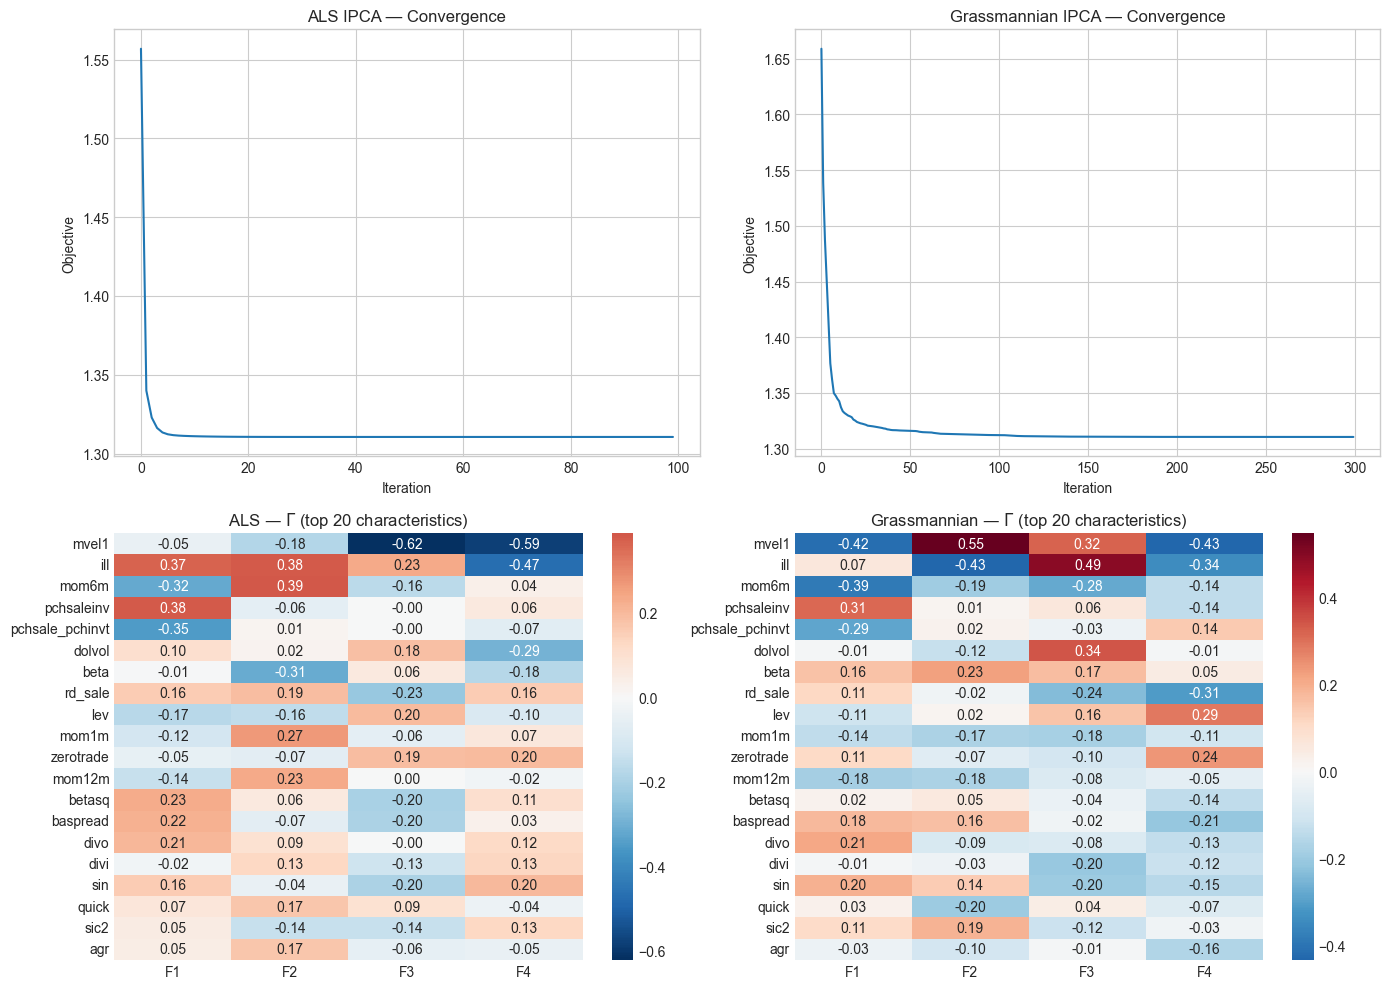

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Convergence ---
axes[0, 0].plot(hist_als)
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Objective')
axes[0, 0].set_title('ALS IPCA — Convergence')

axes[0, 1].plot(hist_grass)
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Objective')
axes[0, 1].set_title('Grassmannian IPCA — Convergence')

# --- Gamma heatmaps (top 20 characteristics by max absolute loading) ---
max_loading = np.maximum(
    np.max(np.abs(Gamma_als), axis=1),
    np.max(np.abs(Gamma_grass), axis=1),
)
top_idx = np.argsort(max_loading)[-20:][::-1]
top_char_names = [char_cols[i] for i in top_idx]

sns.heatmap(
    pd.DataFrame(Gamma_als[top_idx], index=top_char_names,
                 columns=[f'F{k+1}' for k in range(K)]),
    cmap='RdBu_r', center=0, ax=axes[1, 0], annot=True, fmt='.2f',
)
axes[1, 0].set_title('ALS — $\\Gamma$ (top 20 characteristics)')

sns.heatmap(
    pd.DataFrame(Gamma_grass[top_idx], index=top_char_names,
                 columns=[f'F{k+1}' for k in range(K)]),
    cmap='RdBu_r', center=0, ax=axes[1, 1], annot=True, fmt='.2f',
)
axes[1, 1].set_title('Grassmannian — $\\Gamma$ (top 20 characteristics)')

plt.tight_layout()
plt.show()

## 6. Estimated Factors

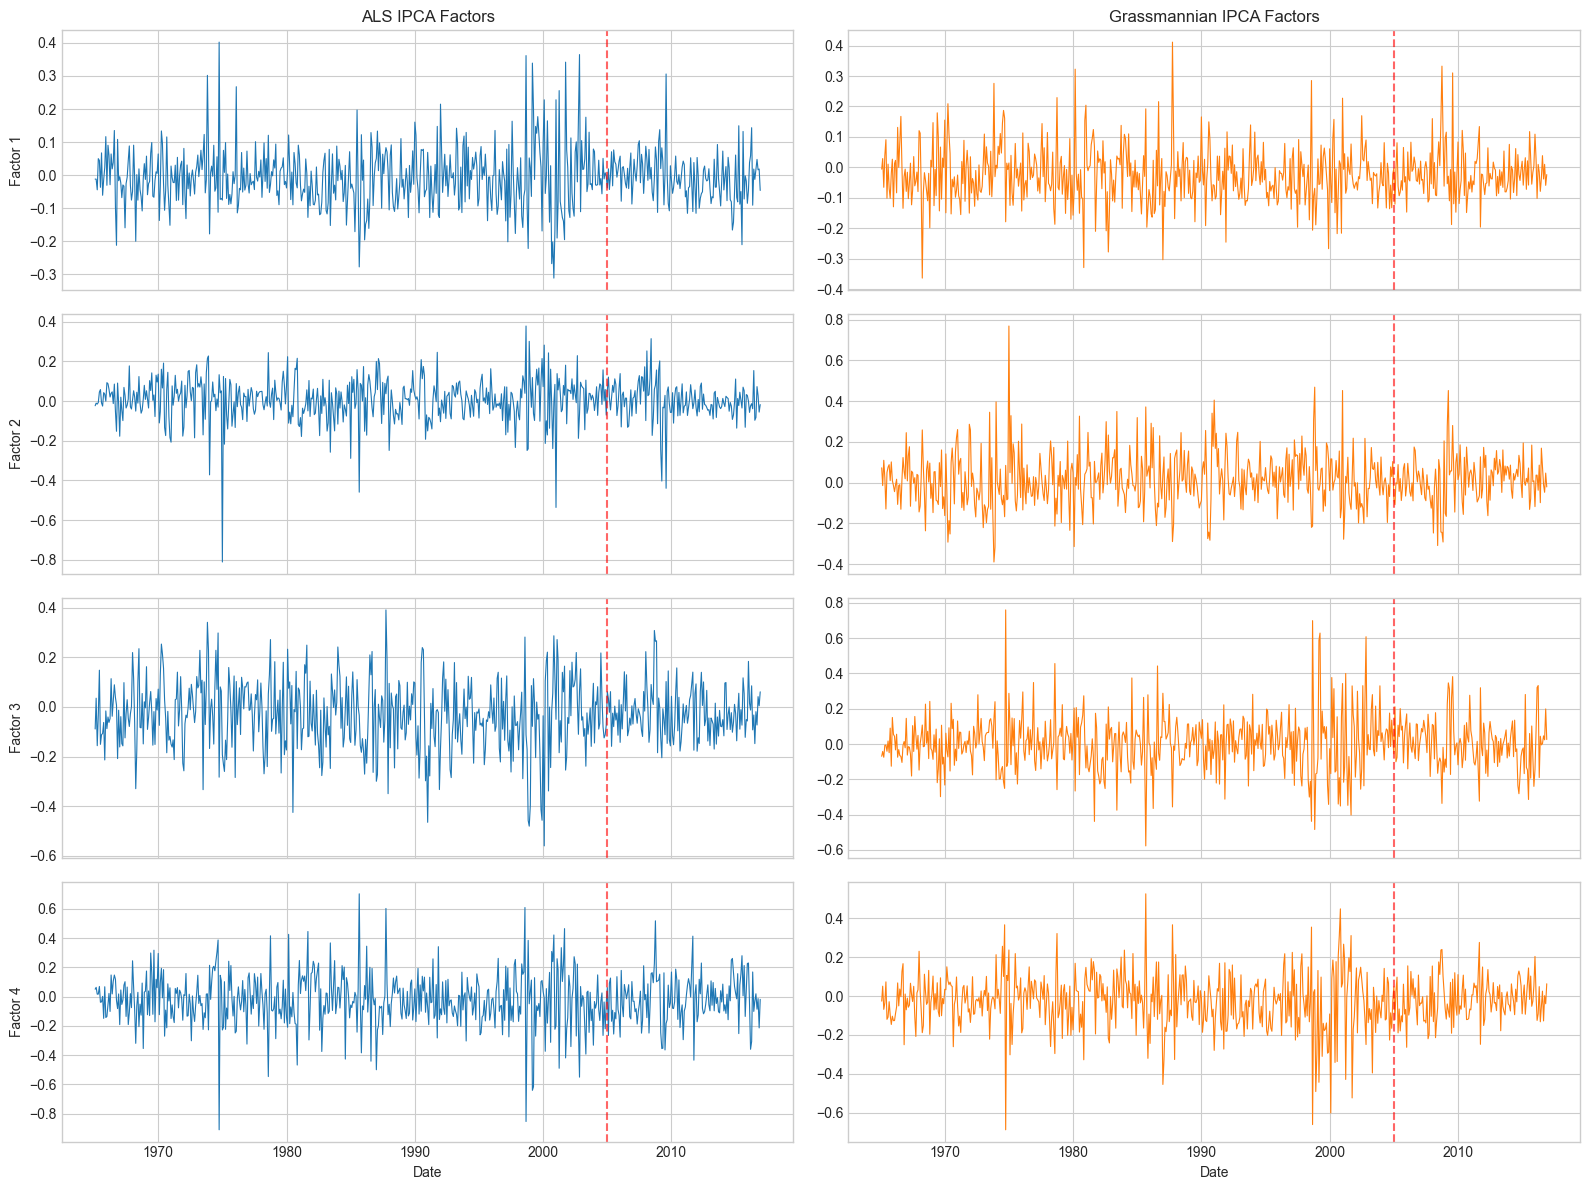

In [10]:
# Combine IS and OOS factors
all_factors_als = np.vstack([f_als_train, als_oos['factors']])
all_factors_grass = np.vstack([f_grass_train, grass_oos['factors']])
all_dates = pd.to_datetime([str(m) for m in months], format='%Y%m')

fig, axes = plt.subplots(K, 2, figsize=(16, 3 * K), sharex=True)

for k in range(K):
    axes[k, 0].plot(all_dates, all_factors_als[:, k], linewidth=0.8)
    axes[k, 0].axvline(pd.Timestamp('2005-01-01'), color='red', ls='--', alpha=0.6)
    axes[k, 0].set_ylabel(f'Factor {k+1}')
    if k == 0:
        axes[k, 0].set_title('ALS IPCA Factors')

    axes[k, 1].plot(all_dates, all_factors_grass[:, k], linewidth=0.8, color='C1')
    axes[k, 1].axvline(pd.Timestamp('2005-01-01'), color='red', ls='--', alpha=0.6)
    if k == 0:
        axes[k, 1].set_title('Grassmannian IPCA Factors')

axes[-1, 0].set_xlabel('Date')
axes[-1, 1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 7. Portfolio Analysis (OOS)

In [11]:
def quintile_analysis(test_rets_raw, test_Z, Gamma, lambda_hat, label=""):
    """Sort stocks into quintiles by predicted expected return and compute portfolio returns."""
    T_test, N_test = test_rets_raw.shape
    n_quintiles = 5
    quintile_rets = {q: [] for q in range(n_quintiles)}

    for t in range(T_test):
        preds_t = test_Z[t] @ Gamma @ lambda_hat  # (N,)
        rets_t = test_rets_raw[t]
        valid = ~np.isnan(rets_t)
        if valid.sum() < n_quintiles:
            continue

        preds_valid = preds_t[valid]
        rets_valid = rets_t[valid]
        breaks = np.percentile(preds_valid, np.linspace(0, 100, n_quintiles + 1))

        for q in range(n_quintiles):
            if q == n_quintiles - 1:
                mask = (preds_valid >= breaks[q]) & (preds_valid <= breaks[q + 1])
            else:
                mask = (preds_valid >= breaks[q]) & (preds_valid < breaks[q + 1])
            if mask.sum() > 0:
                quintile_rets[q].append(np.mean(rets_valid[mask]))

    avg = [np.mean(quintile_rets[q]) * 12 for q in range(n_quintiles)]
    std = [np.std(quintile_rets[q]) * np.sqrt(12) for q in range(n_quintiles)]
    sharpe = [avg[q] / std[q] if std[q] > 0 else 0 for q in range(n_quintiles)]

    ls = np.array(quintile_rets[n_quintiles - 1]) - np.array(quintile_rets[0])
    ls_avg = np.mean(ls) * 12
    ls_std = np.std(ls) * np.sqrt(12)
    ls_sharpe = ls_avg / ls_std if ls_std > 0 else 0

    return {
        'avg': avg, 'std': std, 'sharpe': sharpe,
        'ls_returns': ls, 'ls_avg': ls_avg, 'ls_std': ls_std, 'ls_sharpe': ls_sharpe,
    }


pf_als = quintile_analysis(test_rets_raw, test_Z, Gamma_als, lambda_als, 'ALS')
pf_grass = quintile_analysis(test_rets_raw, test_Z, Gamma_grass, lambda_grass, 'Grass')

# --- Print ---
print(f"{'':12s} {'--- ALS IPCA ---':>32s}   {'--- Grassmannian ---':>32s}")
print(f"{'Quintile':12s} {'AvgRet':>8s} {'Vol':>8s} {'Sharpe':>7s}   {'AvgRet':>8s} {'Vol':>8s} {'Sharpe':>7s}")
print("-" * 80)
for q in range(5):
    print(f"Q{q+1:<11d} {pf_als['avg'][q]*100:>7.2f}% {pf_als['std'][q]*100:>7.2f}% {pf_als['sharpe'][q]:>6.2f}"
          f"   {pf_grass['avg'][q]*100:>7.2f}% {pf_grass['std'][q]*100:>7.2f}% {pf_grass['sharpe'][q]:>6.2f}")
print("-" * 80)
print(f"{'L/S (Q5-Q1)':<12s} {pf_als['ls_avg']*100:>7.2f}% {pf_als['ls_std']*100:>7.2f}% {pf_als['ls_sharpe']:>6.2f}"
      f"   {pf_grass['ls_avg']*100:>7.2f}% {pf_grass['ls_std']*100:>7.2f}% {pf_grass['ls_sharpe']:>6.2f}")

                             --- ALS IPCA ---               --- Grassmannian ---
Quintile       AvgRet      Vol  Sharpe     AvgRet      Vol  Sharpe
--------------------------------------------------------------------------------
Q1             10.29%   15.06%   0.68     10.30%   15.05%   0.68
Q2              9.98%   15.53%   0.64     10.00%   15.55%   0.64
Q3             11.36%   17.24%   0.66     11.31%   17.30%   0.65
Q4             11.08%   17.97%   0.62     11.06%   17.91%   0.62
Q5             15.08%   21.96%   0.69     15.11%   21.96%   0.69
--------------------------------------------------------------------------------
L/S (Q5-Q1)     4.79%   14.20%   0.34      4.81%   14.23%   0.34


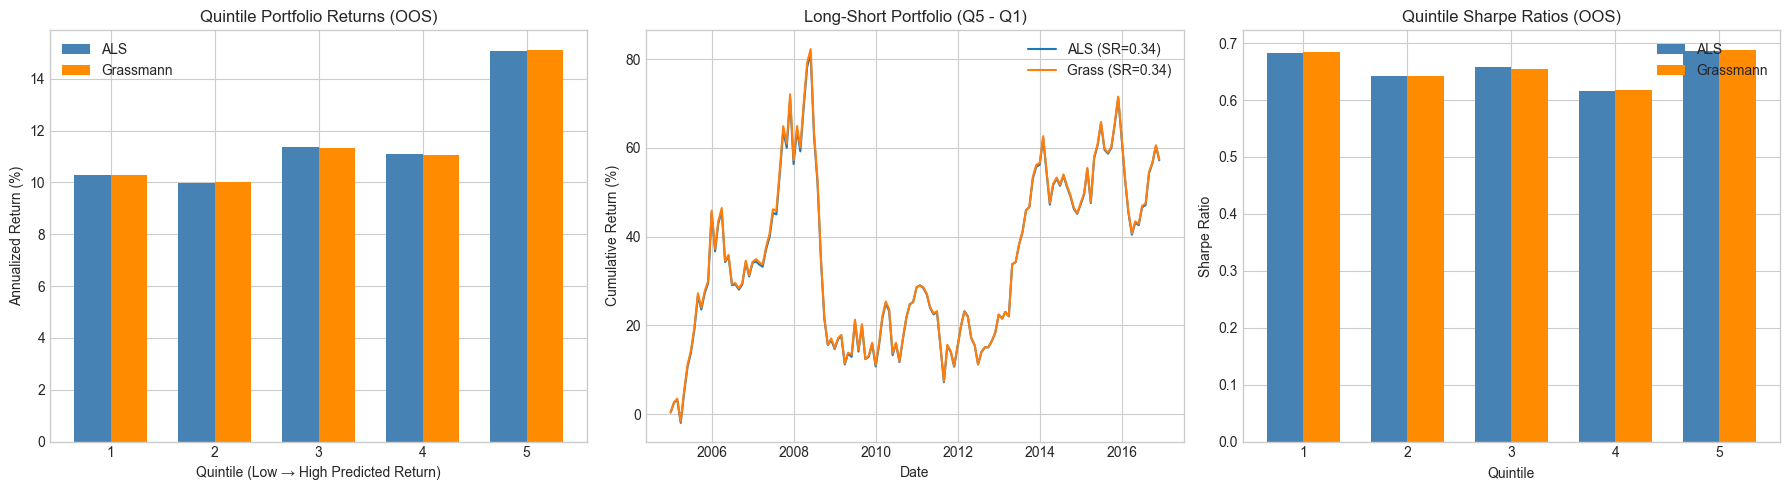

In [12]:
# --- Portfolio plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Quintile bar charts
x = np.arange(5) + 1
w = 0.35
axes[0].bar(x - w/2, [r * 100 for r in pf_als['avg']], w, label='ALS', color='steelblue')
axes[0].bar(x + w/2, [r * 100 for r in pf_grass['avg']], w, label='Grassmann', color='darkorange')
axes[0].set_xlabel('Quintile (Low \u2192 High Predicted Return)')
axes[0].set_ylabel('Annualized Return (%)')
axes[0].set_title('Quintile Portfolio Returns (OOS)')
axes[0].set_xticks(x)
axes[0].legend()

# Cumulative L/S returns
oos_dates = all_dates[split_idx:split_idx + len(pf_als['ls_returns'])]
cum_als = np.cumprod(1 + pf_als['ls_returns']) - 1
cum_grass = np.cumprod(1 + pf_grass['ls_returns']) - 1
axes[1].plot(oos_dates, cum_als * 100, label=f"ALS (SR={pf_als['ls_sharpe']:.2f})")
axes[1].plot(oos_dates, cum_grass * 100, label=f"Grass (SR={pf_grass['ls_sharpe']:.2f})")
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Return (%)')
axes[1].set_title('Long-Short Portfolio (Q5 - Q1)')
axes[1].legend()

# Sharpe ratio comparison
axes[2].bar(x - w/2, pf_als['sharpe'], w, label='ALS', color='steelblue')
axes[2].bar(x + w/2, pf_grass['sharpe'], w, label='Grassmann', color='darkorange')
axes[2].set_xlabel('Quintile')
axes[2].set_ylabel('Sharpe Ratio')
axes[2].set_title('Quintile Sharpe Ratios (OOS)')
axes[2].set_xticks(x)
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. Summary

In [13]:
print(f"{'':30s} {'ALS IPCA':>12s}  {'Grassmann':>12s}")
print("=" * 58)
print(f"{'Final objective':30s} {hist_als[-1]:12.4f}  {hist_grass[-1]:12.4f}")
print(f"{'IS Total R² (%)':30s} {als_is['total_r2']*100:12.2f}  {grass_is['total_r2']*100:12.2f}")
print(f"{'IS Predictive R² (%)':30s} {als_is['pred_r2']*100:12.2f}  {grass_is['pred_r2']*100:12.2f}")
print(f"{'OOS Total R² (%)':30s} {als_oos['total_r2']*100:12.2f}  {grass_oos['total_r2']*100:12.2f}")
print(f"{'OOS Predictive R² (%)':30s} {als_oos['pred_r2']*100:12.2f}  {grass_oos['pred_r2']*100:12.2f}")
print("-" * 58)
print(f"{'L/S Sharpe (OOS)':30s} {pf_als['ls_sharpe']:12.2f}  {pf_grass['ls_sharpe']:12.2f}")
print(f"{'Iterations':30s} {als.n_iterations:12d}  {len(hist_grass):12d}")
print(f"{'Wall time (s)':30s} {als_time:12.1f}  {grass_time:12.1f}")
print(f"{'Parameters (L x K)':30s} {L * K:12d}  {L * K:12d}")

                                   ALS IPCA     Grassmann
Final objective                      1.3105        1.3105
IS Total R² (%)                       35.16         35.16
IS Predictive R² (%)                   1.56          1.56
OOS Total R² (%)                      35.31         35.31
OOS Predictive R² (%)                  0.79          0.79
----------------------------------------------------------
L/S Sharpe (OOS)                       0.34          0.34
Iterations                               99           300
Wall time (s)                         111.0          66.4
Parameters (L x K)                      380           380
